Initializing Comprehensive EDA for: IEF_Shipments_FY26_cleaned.csv

=== 1. DATASET SHAPE & HEALTH ===
Total Shipments (Rows): 7281
Total Features (Columns): 24

=== 2. MISSING VALUES DIAGNOSTIC ===
Columns with missing data that require imputation/dropping:
               Missing Count  Missing Percentage (%)
Customs_Value           3068                   42.14

=== 3. BASELINE PERFORMANCE (TARGET VARIABLE) ===
Raw On-Time vs. Late Breakdown:
 - On-Time (1): 4612 shipments (63.34%)
 - Late/Failed (0): 2669 shipments (36.66%)

=== 4. FAILURE BUCKET DISTRIBUTION ===
Top 5 Reasons for Delay (if recorded):
Failure_Bucket
NO_DELAY              4933
CLEARANCE             1029
TRANSIT-Processing     608
EXCLUDE                444
ORIGIN                 205
Name: count, dtype: int64

=== 5. TOP VOLUME ORIGIN/DESTINATION PAIRS ===
orig_cntry_cd dest_cntry_cd  Volume
           US            PH    3245
           CN            PH     978
           SG            PH     946
           HK         

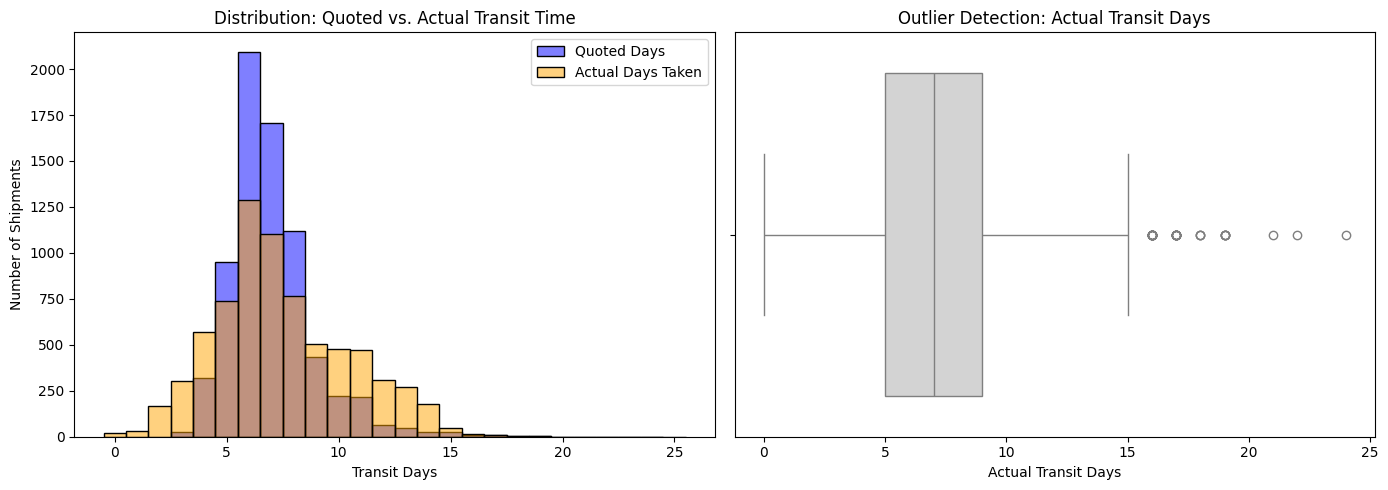

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def run_comprehensive_eda(file_path):
    """
    Performs full diagnostics and visualizations on the raw shipment dataset.
    """
    print(f"Initializing Comprehensive EDA for: {file_path}\n")

    # 1. Load the raw data
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: Could not find {file_path}")
        return None

    # --- PART A: TEXT DIAGNOSTICS ---

    # 2. Dataset Shape and High-Level Health
    print("=== 1. DATASET SHAPE & HEALTH ===")
    print(f"Total Shipments (Rows): {df.shape[0]}")
    print(f"Total Features (Columns): {df.shape[1]}")

    print("\n=== 2. MISSING VALUES DIAGNOSTIC ===")
    missing_data = df.isnull().sum()
    missing_pct = (missing_data / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_data, 'Missing Percentage (%)': missing_pct})
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)

    if missing_df.empty:
        print("No missing values found. Data is perfectly dense.")
    else:
        print("Columns with missing data that require imputation/dropping:")
        print(missing_df.round(2))

    # 3. Target Variable Analysis (Current Network Performance)
    print("\n=== 3. BASELINE PERFORMANCE (TARGET VARIABLE) ===")
    if 'Delivered_in_Commit' in df.columns:
        compliance_counts = df['Delivered_in_Commit'].value_counts()
        compliance_pct = df['Delivered_in_Commit'].value_counts(normalize=True) * 100

        print("Raw On-Time vs. Late Breakdown:")
        for status, count in compliance_counts.items():
            pct = compliance_pct[status]
            label = "On-Time (1)" if status == 1 else "Late/Failed (0)"
            print(f" - {label}: {count} shipments ({pct:.2f}%)")
    else:
        print("Target variable 'Delivered_in_Commit' not found.")

    # 4. Delay Categorization Analysis
    print("\n=== 4. FAILURE BUCKET DISTRIBUTION ===")
    if 'Failure_Bucket' in df.columns:
        top_failures = df['Failure_Bucket'].value_counts().head(5)
        print("Top 5 Reasons for Delay (if recorded):")
        print(top_failures)

    # 5. Geographic Imbalance Analysis (Top Lanes)
    print("\n=== 5. TOP VOLUME ORIGIN/DESTINATION PAIRS ===")
    lane_volume = df.groupby(['orig_cntry_cd', 'dest_cntry_cd']).size().reset_index(name='Volume')
    lane_volume = lane_volume.sort_values(by='Volume', ascending=False).head(5)
    print(lane_volume.to_string(index=False))


    # --- PART B: VISUALIZATIONS ---
    print("\nGenerating visual distributions...")

    # 6. Sanitize Data specifically for Plotting
    # This ensures Matplotlib doesn't crash on nulls or strings, without deleting rows from the main 'df'
    plot_data = df[['Quoted_Transit_Days', 'Actual_Transit_Days']].apply(pd.to_numeric, errors='coerce').dropna()

    # 7. Set up the figure layout (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot A: Overlapping Histogram
    sns.histplot(data=plot_data, x='Quoted_Transit_Days', color='blue', label='Quoted Days',
                 alpha=0.5, ax=axes[0], binwidth=1, discrete=True)

    sns.histplot(data=plot_data, x='Actual_Transit_Days', color='orange', label='Actual Days Taken',
                 alpha=0.5, ax=axes[0], binwidth=1, discrete=True)

    axes[0].set_title('Distribution: Quoted vs. Actual Transit Time')
    axes[0].set_xlabel('Transit Days')
    axes[0].set_ylabel('Number of Shipments')
    axes[0].legend()

    # Plot B: Boxplot for Outlier Detection
    sns.boxplot(data=plot_data, x='Actual_Transit_Days', ax=axes[1], color='lightgray')
    axes[1].set_title('Outlier Detection: Actual Transit Days')
    axes[1].set_xlabel('Actual Transit Days')

    plt.tight_layout()
    plt.show()

    return df

# Execution
raw_data = run_comprehensive_eda('IEF_Shipments_FY26_cleaned.csv')